# Portfolio Dashboard

Notebook-first analytics for Schwab accounts.  
Edit the **Parameters** cell, then **Run All**.

In [56]:
import sys
sys.path.insert(0, '../src')

import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from report import run_report
import plots
import pandas as pd

In [57]:
# ============================================================
# PARAMETERS — edit this cell
# ============================================================

# Which accounts to include.
# Options: "Retirement", "Trade_and_leaps", or both.
ACCOUNTS = ["Retirement", "Trade_and_leaps"]

# Date range.  Both are required for meaningful annualized metrics.
# Use ISO format "YYYY-MM-DD".  Set to None only for exploratory runs.
START_DATE = "2024-04-15"
END_DATE   = None          # None = latest available date in the data

# Risk-free rate for Sharpe ratio (annualized decimal, e.g. 0.045 = 4.5%)
RISK_FREE_RATE = 0.0

# Set False to skip all benchmark work: no API call, no metrics column,
# no chart overlays, no benchmark artifacts in the report.
REPORT_INCLUDE_BENCHMARK = True
BENCHMARK = "SPY"          # ticker — only used when REPORT_INCLUDE_BENCHMARK = True

# Paths (relative to this notebook — all resolve into portfolio_dashboard/)
RAW_DIR       = "../data/raw"
PROCESSED_DIR = "../data/processed"
REPORTS_DIR   = "../reports"

In [58]:
# ============================================================
# Load data and run pipeline
# ============================================================
results = run_report(
    raw_dir        = RAW_DIR,
    accounts       = ACCOUNTS,
    start_date     = START_DATE,
    end_date       = END_DATE,
    risk_free_rate = RISK_FREE_RATE,
    benchmark      = BENCHMARK if REPORT_INCLUDE_BENCHMARK else None,
)
print("Data loaded.  Date range:",
      results['nav'].index[0].date(), "\u2192",
      results['nav'].index[-1].date())

[benchmark] SPY: 501 rows saved → SPY.csv
Data loaded.  Date range: 2024-04-15 → 2026-04-15


In [59]:
# ============================================================
# Metrics summary
# ============================================================
results['metrics']

,Value,Benchmark
Start date,2024-04-15,—
End date,2026-04-15,—
Start NAV ($),"201,124.54",—
End NAV ($),"397,829.46",—
Net external cash flows ($),"68,768.31",—
Net investment gain ($),"127,936.61",—
Total return (TWR),62.19%,40.67%
Annualized return,27.37%,18.67%
Annualized volatility,24.12%,16.73%
Sharpe ratio,0.81,1.11


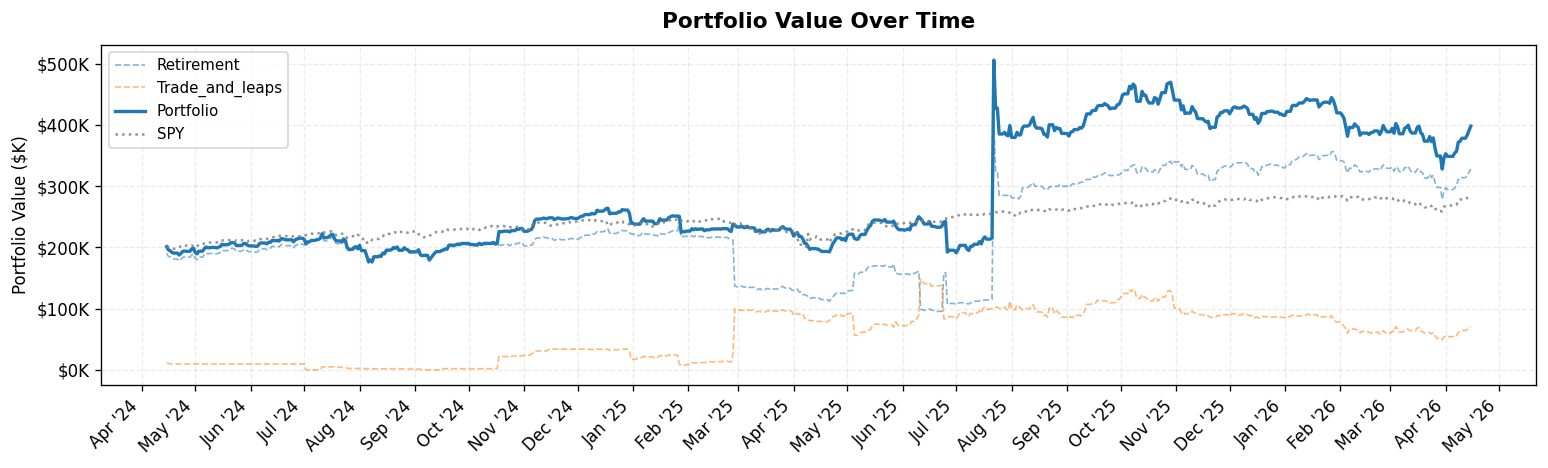

In [60]:
# ============================================================
# Chart 1 — Portfolio value over time
# ============================================================
plots.plot_equity_curve(
    results['nav'],
    account_navs = results['account_navs'] if len(ACCOUNTS) > 1 else None,
    benchmark    = results['benchmark_returns'],
);

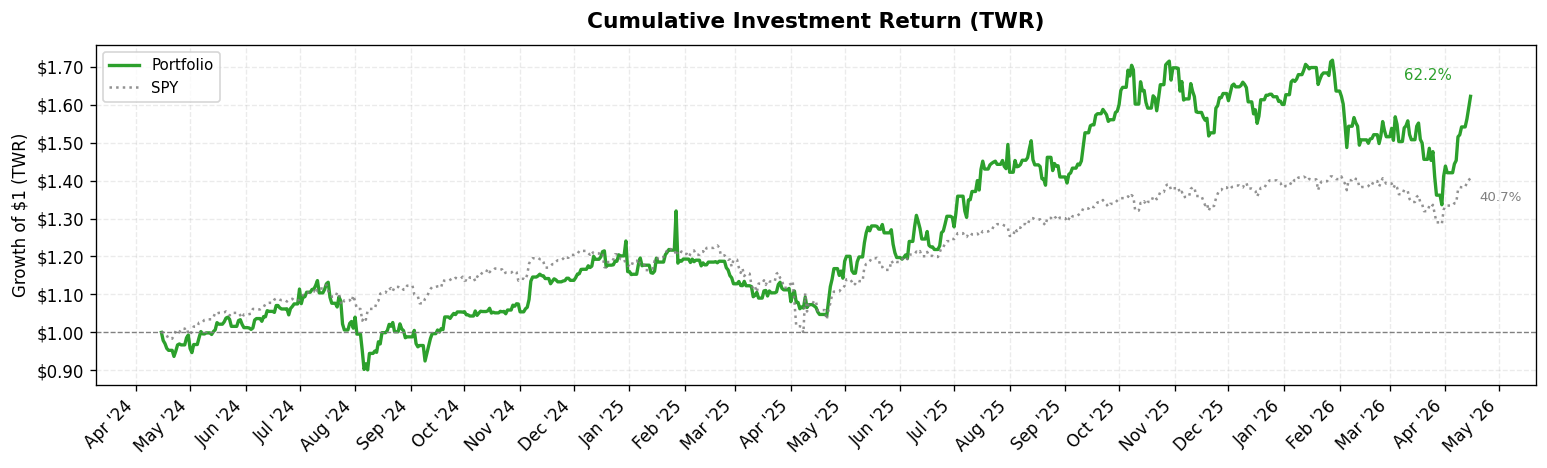

In [61]:
# ============================================================
# Chart 2 — Cumulative investment return (TWR, $1 basis)
# ============================================================
plots.plot_cum_return(results['cum_return'], benchmark=results['benchmark_returns']);

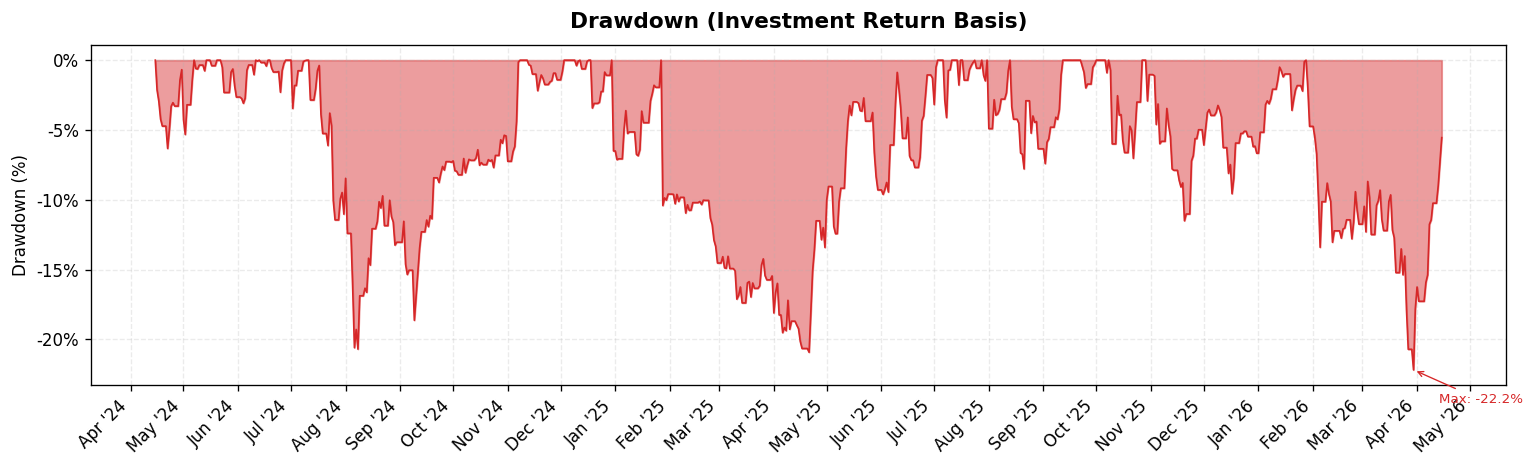

In [62]:
# ============================================================
# Chart 3 — Drawdown on TWR curve
# ============================================================
plots.plot_drawdown(results['drawdown']);

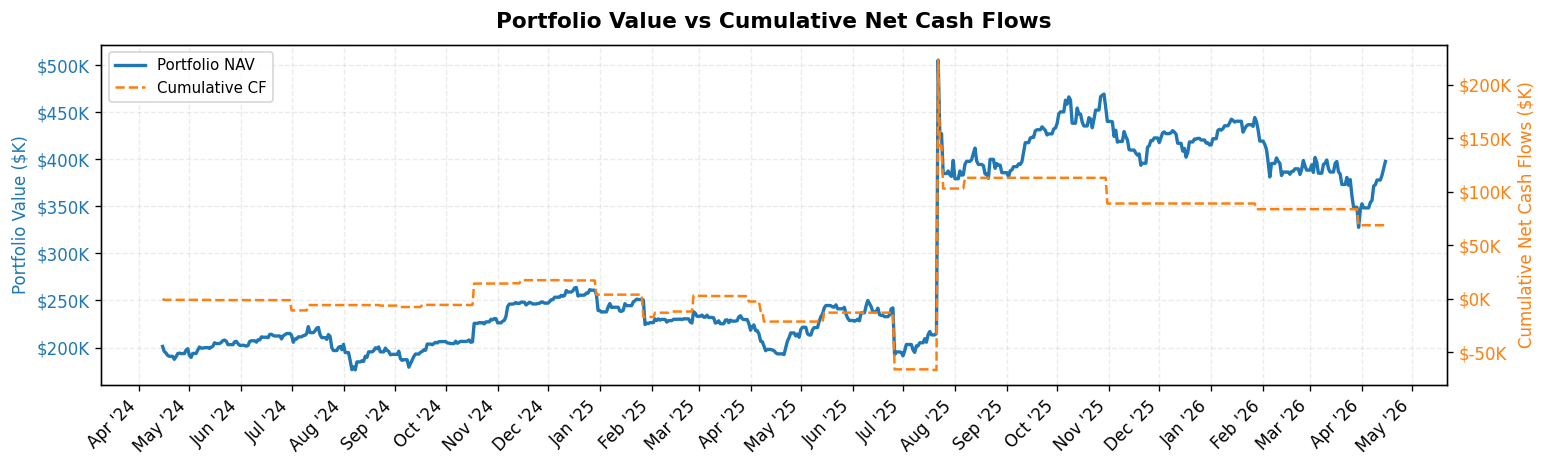

In [63]:
# ============================================================
# Chart 4 — Portfolio NAV vs cumulative net cash flows
# ============================================================
plots.plot_nav_vs_cashflows(
    results['nav'],
    results['cumulative_cf'],
);

In [64]:
# ============================================================
# Monthly returns table
# ============================================================
mon = results['monthly_rets'].dropna()
mon_pct = mon.map(lambda x: f"{x:.2%}")
mon_pct.name = "Monthly Return"
mon_pct

date
2024-04-30    -0.68%
2024-05-31     1.94%
2024-06-30     6.17%
2024-07-31    -5.94%
2024-08-31    -2.26%
2024-09-30     6.59%
2024-10-31     2.04%
2024-11-30     5.80%
2024-12-31     2.02%
2025-01-31     2.85%
2025-02-28    -5.46%
2025-03-31    -1.08%
2025-04-30     2.41%
2025-05-31     4.76%
2025-06-30     8.84%
2025-07-31    14.75%
2025-08-31    -5.74%
2025-09-30    12.29%
2025-10-31     7.22%
2025-11-30    -3.99%
2025-12-31    -1.77%
2026-01-31     2.21%
2026-02-28    -7.36%
2026-03-31    -6.88%
2026-04-30    14.93%
Freq: ME, Name: Monthly Return, dtype: str

In [65]:
# ============================================================
# Daily cash flows table (top 20 largest by absolute value)
# ============================================================
cf = results['daily_cf']
cf_nz = cf[cf != 0].sort_values(key=lambda s: s.abs(), ascending=False).head(20)
cf_nz.map(lambda x: f"${x:,.2f}").rename("Net External CF").to_frame()

,Net External CF
date,
2025-07-22,"$289,411.00"
2025-07-23,"$-79,950.00"
2025-06-26,"$-52,986.00"
2025-07-25,"$-40,000.00"
2025-10-31,"$-24,000.00"
2025-01-27,"$-20,868.76"
2024-10-18,"$20,000.00"
2026-03-30,"$-15,000.00"
2025-02-26,"$15,000.00"


In [66]:
# ============================================================
# Generate final report
# ============================================================
from report import generate_final_report

report_path = generate_final_report(
    results,
    output_dir     = REPORTS_DIR,
    processed_base = PROCESSED_DIR,
)
print("Report saved:", report_path)

[report] Processed artifacts -> ..\data\processed\20260416_121505
[report] HTML report         -> ..\reports\report_20260416_121505.html
Report saved: ..\reports\report_20260416_121505.html
